# Find all pixels within a given radius from a lat/lon point.

* Use the `haversine` formula https://en.wikipedia.org/wiki/Haversine_formula to calc distance between chosen lat/lon and *all other* lats/lons
* Select out ones less than radius
* Use to calc the environment within a given radius from a point.
* Should be easy to feed in lat/lon from your favourite tracker plus a radius of interest.
* Mark Muetzelfeldt, mark.muetzelfeldt@reading.ac.uk

In [1]:
import easygems.healpix as egh
import healpix as hp
import intake
import numpy as np

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance in kilometers between two points 
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.asin(np.sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r

## Synthetic data test

In [5]:
z = 6

In [6]:
lon, lat = hp.pix2ang(2**z, np.arange(12 * 4**z), nest=True, lonlat=True)

73


<Figure size 640x480 with 0 Axes>

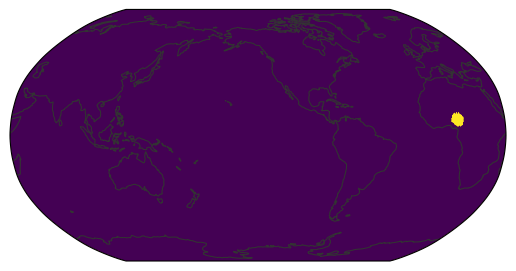

In [7]:
chosen_lat = 10  # deg N
chosen_lon = 10  # deg E
radius = 500  # km
idx = haversine(lon, lat, chosen_lon, chosen_lat) < radius
print(idx.sum())
egh.healpix_show(idx)

## Real simulation data extract env.

In [18]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [19]:
ds = cat['um_glm_n2560_RAL3p3'](zoom=z, time='PT1H').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [20]:
chosen_lat = 10  # deg N
chosen_lon = 10  # deg E
radius = 500  # km
idx = haversine(lon, lat, chosen_lon, chosen_lat) < radius
ds.tas.sel(time='2020-03-01 00:00').sel(cell=idx).mean().compute()

<xarray.DataArray 'tas' ()> Size: 4B
array(295.30685, dtype=float32)
Coordinates:
    crs      float64 8B nan
    time     datetime64[ns] 8B 2020-03-01

In [9]:
import healpy

In [ ]:
chosen_lat = 10  # deg N
chosen_lon = 10  # deg E
radius = 1000  # km

egh.healpix_show(healpy.query_disc(2**z, )